# Study and Implementation of an ID3 Decision Tree for Student Performance Classification

**Prototype version for A2 Option 1**

This notebook contains a scikit-learn decision tree reference model and a custom ID3 implementation developed from scratch. It includes data preprocessing, model evaluation, tree-depth experiments and the main ID3 components such as entropy, information gain, best split and recursive tree construction.

## 1. Install and import libraries

In [1]:
!pip -q install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Load the UCI Student Performance dataset

For this prototype:
- **Input:** selected student features
- **Output:** binary class `Pass` or `Fail`

In [2]:
student_performance = fetch_ucirepo(id=320)
X_raw = student_performance.data.features.copy()
y_raw = student_performance.data.targets.copy()

print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)
display(X_raw.head())
display(y_raw.head())

Feature shape: (649, 30)
Target shape: (649, 3)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,yes,no,no,4,3,4,1,1,3,4
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,yes,yes,no,5,3,3,1,1,3,2
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,yes,yes,no,4,3,2,2,3,3,6
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,yes,yes,3,2,2,1,1,5,0
4,GP,F,16,U,GT3,T,3,3,other,other,...,yes,no,no,4,3,2,1,2,5,0


,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


## 3. Inspect columns

In [3]:
print("Input columns:")
print(X_raw.columns.tolist())
print("\nTarget columns:")
print(y_raw.columns.tolist())

Input columns:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Target columns:
['G1', 'G2', 'G3']


## 4. Define the classification target

We convert the final grade `G3` into:
- `Pass = 1` if `G3 >= 10`
- `Fail = 0` if `G3 < 10`

To make the task more meaningful, we avoid using `G1` and `G2` in this first prototype because they are previous grades and are highly related to the final grade.

In [4]:
full_df = pd.concat([X_raw, y_raw], axis=1)
if "G3" not in full_df.columns:
    raise ValueError("G3 column was not found. Please inspect the dataset columns above.")

full_df["Pass"] = (full_df["G3"] >= 10).astype(int)
feature_df = full_df.drop(columns=["G1", "G2", "G3", "Pass"], errors="ignore")
target = full_df["Pass"]

print(target.value_counts())
print("\nPass rate:", round(target.mean(), 3))

Pass
1    549
0    100
Name: count, dtype: int64

Pass rate: 0.846


## 5. Select a simple subset of features

In [5]:
preferred_features = [
    "studytime", "failures", "absences", "schoolsup",
    "famsup", "internet", "higher", "activities"
]
selected_features = [c for c in preferred_features if c in feature_df.columns]
X = feature_df[selected_features].copy() if selected_features else feature_df.copy()
print("Selected features:", X.columns.tolist())
display(X.head())

Selected features: ['studytime', 'failures', 'absences', 'schoolsup', 'famsup', 'internet', 'higher', 'activities']


,studytime,failures,absences,schoolsup,famsup,internet,higher,activities
0,2,0,4,yes,no,no,yes,no
1,2,0,2,no,yes,yes,yes,no
2,2,0,6,yes,no,yes,yes,no
3,3,0,0,no,yes,yes,yes,yes
4,2,0,0,no,yes,no,yes,no


## 6. Train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, target, test_size=0.20, random_state=42, stratify=target
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 519
Testing samples: 130


## 7. Preprocess categorical variables

In [7]:
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

## 8. Build a simple Decision Tree prototype

This is an off-the-shelf reference implementation. For the final Option 1 project, it should later be compared with your own implementation of the main ID3 logic.

In [8]:
prototype_model = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("tree", DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42))
    ]
)
prototype_model.fit(X_train, y_train)
y_pred = prototype_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7846


## 9. Evaluation

              precision    recall  f1-score   support

        Fail       0.28      0.25      0.26        20
        Pass       0.87      0.88      0.87       110

    accuracy                           0.78       130
   macro avg       0.57      0.57      0.57       130
weighted avg       0.78      0.78      0.78       130



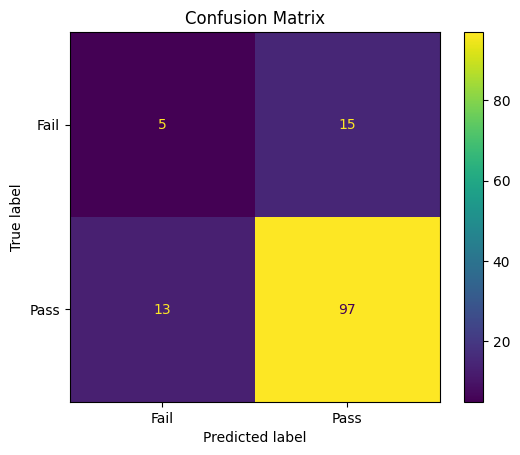

In [9]:
print(classification_report(y_test, y_pred, target_names=["Fail", "Pass"]))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"]).plot()
plt.title("Confusion Matrix")
plt.show()

## 10. Visualise the decision tree

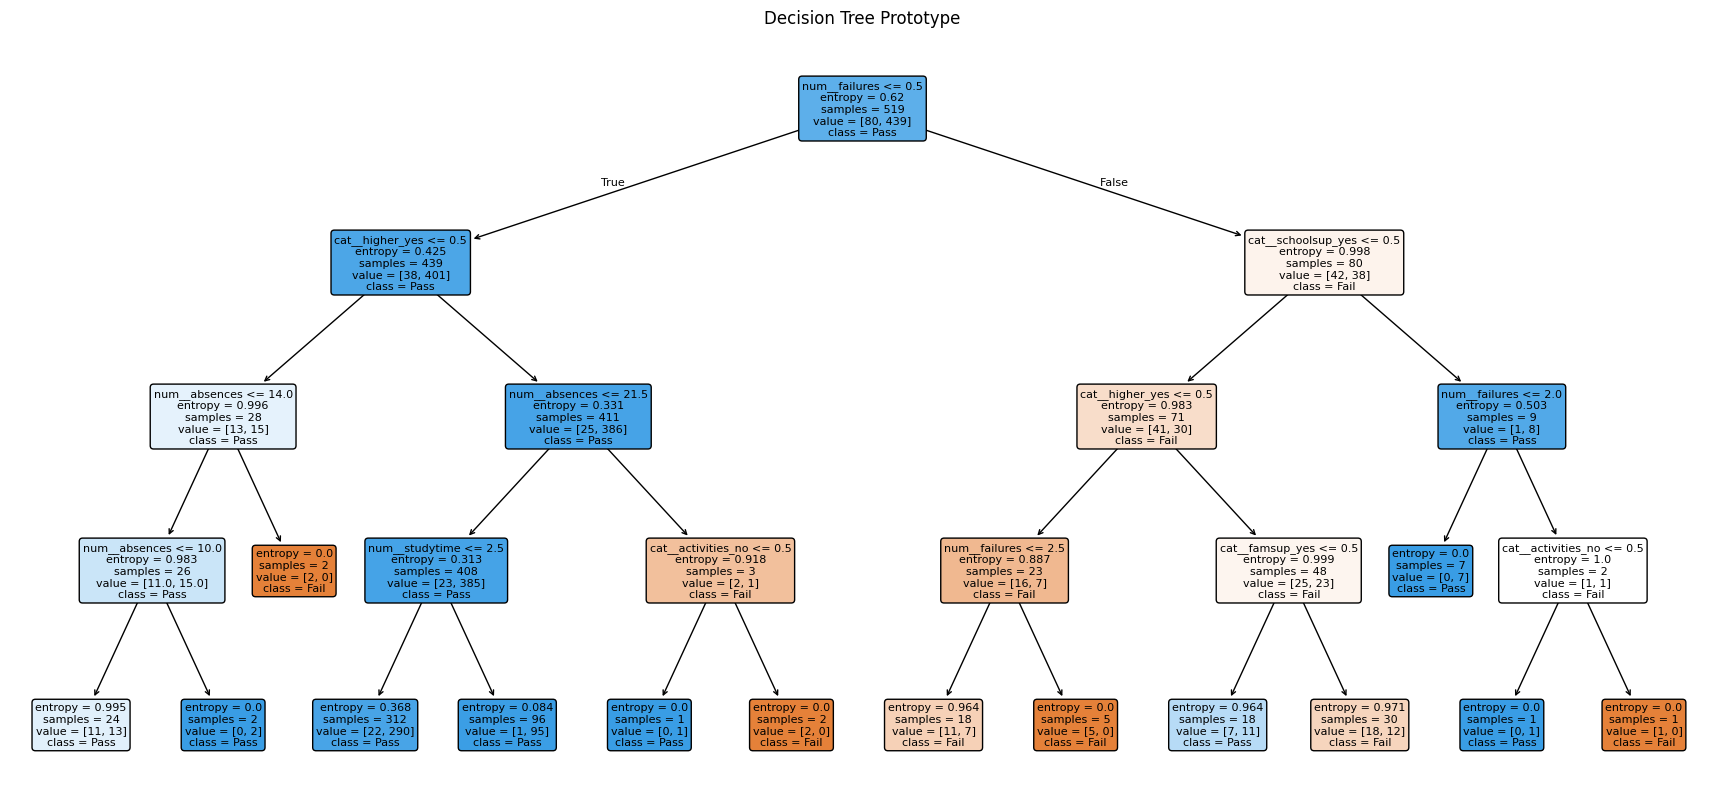

In [10]:
fitted_preprocessor = prototype_model.named_steps["preprocess"]
fitted_tree = prototype_model.named_steps["tree"]
feature_names = fitted_preprocessor.get_feature_names_out()

plt.figure(figsize=(22, 10))
plot_tree(
    fitted_tree, feature_names=feature_names, class_names=["Fail", "Pass"],
    filled=True, rounded=True, fontsize=8
)
plt.title("Decision Tree Prototype")
plt.show()

## 11. First experiment: tree depth

In [11]:
results = []
for depth in [1, 2, 3, 4, 5, 6, 8, None]:
    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("tree", DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=42))
    ])
    model.fit(X_train, y_train)
    results.append({
        "max_depth": "None" if depth is None else depth,
        "train_accuracy": accuracy_score(y_train, model.predict(X_train)),
        "test_accuracy": accuracy_score(y_test, model.predict(X_test))
    })

depth_results = pd.DataFrame(results)
display(depth_results)

,max_depth,train_accuracy,test_accuracy
0,1,0.853565,0.800000
1,2,0.867052,0.792308
2,3,0.872832,0.776923
3,4,0.884393,0.784615
4,5,0.895954,0.823077
5,6,0.911368,0.784615
6,8,0.932563,0.800000
7,None,0.961464,0.776923


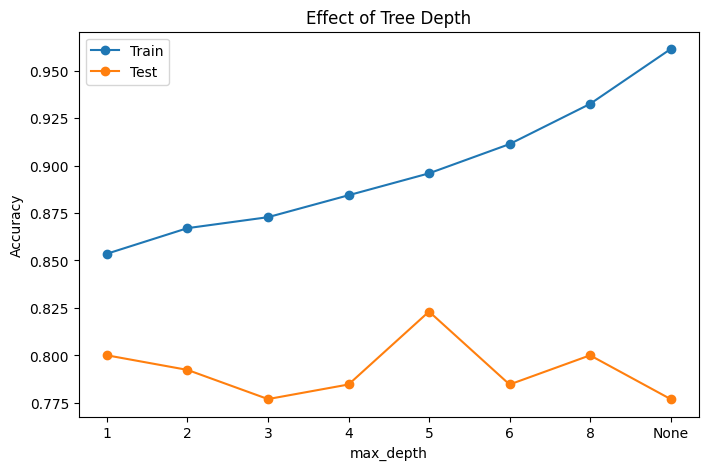

In [12]:
plot_df = depth_results.copy()
plot_df["depth_number"] = list(range(1, len(plot_df) + 1))
plt.figure(figsize=(8, 5))
plt.plot(plot_df["depth_number"], plot_df["train_accuracy"], marker="o", label="Train")
plt.plot(plot_df["depth_number"], plot_df["test_accuracy"], marker="o", label="Test")
plt.xticks(plot_df["depth_number"], depth_results["max_depth"])
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth")
plt.legend()
plt.show()

# 12. Implement ID3 Core Components from Scratch

In [13]:
import numpy as np
import pandas as pd


# 1. Entropy

def entropy(y):
    probabilities = y.value_counts(normalize=True)

    return -sum(
        p * np.log2(p)
        for p in probabilities
        if p > 0
    )



# 2. Information Gain

def information_gain(X_column, y):
    parent_entropy = entropy(y)

    weighted_child_entropy = 0

    for value in X_column.unique():
        mask = X_column == value
        y_subset = y[mask]

        weight = len(y_subset) / len(y)

        weighted_child_entropy += weight * entropy(y_subset)

    return parent_entropy - weighted_child_entropy



# 3. Find Best Split

def best_split(X, y, features):
    best_feature = None
    best_gain = -1

    for feature in features:
        gain = information_gain(X[feature], y)

        if gain > best_gain:
            best_gain = gain
            best_feature = feature

    return best_feature, best_gain

In [14]:

# 4. Build ID3 Tree

def build_tree(
    X,
    y,
    features,
    depth=0,
    max_depth=5,
    min_samples_split=2
):

    # Majority class at this node
    majority_class = y.mode()[0]

    # Stop if all samples belong to the same class
    if y.nunique() == 1:
        return int(y.iloc[0])

    # Stop if no features remain
    if len(features) == 0:
        return int(majority_class)

    # Stop if maximum depth is reached
    if depth >= max_depth:
        return int(majority_class)

    # Stop if too few samples remain
    if len(y) < min_samples_split:
        return int(majority_class)

    # Find feature with highest information gain
    best_feature, gain = best_split(X, y, features)

    if best_feature is None or gain <= 0:
        return int(majority_class)

    tree = {
        "feature": best_feature,
        "information_gain": gain,
        "majority": int(majority_class),
        "branches": {}
    }

    remaining_features = [
        f for f in features
        if f != best_feature
    ]

    # Create one branch for each feature value
    for value in X[best_feature].unique():

        mask = X[best_feature] == value

        X_subset = X.loc[mask].reset_index(drop=True)
        y_subset = y.loc[mask].reset_index(drop=True)

        tree["branches"][value] = build_tree(
            X_subset,
            y_subset,
            remaining_features,
            depth=depth + 1,
            max_depth=max_depth,
            min_samples_split=min_samples_split
        )

    return tree

In [15]:

# 5. Prediction

def predict_one(row, tree):

    # Leaf node
    if not isinstance(tree, dict):
        return tree

    feature = tree["feature"]
    value = row[feature]

    # If this value appeared during training
    if value in tree["branches"]:
        return predict_one(
            row,
            tree["branches"][value]
        )

    # If an unseen value appears, use majority class
    return tree["majority"]


def predict_id3(X, tree):
    return X.apply(
        lambda row: predict_one(row, tree),
        axis=1
    )

In [16]:

# 6. Prepare data for ID3


X_train_id3 = X_train.copy()
X_test_id3 = X_test.copy()

# Convert absences into discrete categories
bins = [-1, 5, 10, 20, float("inf")]
labels = ["0-5", "6-10", "11-20", "21+"]

X_train_id3["absences"] = pd.cut(
    X_train_id3["absences"],
    bins=bins,
    labels=labels
)

X_test_id3["absences"] = pd.cut(
    X_test_id3["absences"],
    bins=bins,
    labels=labels
)

# Convert all features to strings/categorical values
for column in X_train_id3.columns:
    X_train_id3[column] = X_train_id3[column].astype(str)
    X_test_id3[column] = X_test_id3[column].astype(str)

X_train_id3 = X_train_id3.reset_index(drop=True)
X_test_id3 = X_test_id3.reset_index(drop=True)

y_train_id3 = y_train.reset_index(drop=True)
y_test_id3 = y_test.reset_index(drop=True)

features = list(X_train_id3.columns)

print("Features:", features)

Features: ['studytime', 'failures', 'absences', 'schoolsup', 'famsup', 'internet', 'higher', 'activities']


In [17]:

# 7. Train our own ID3


my_id3_tree = build_tree(
    X_train_id3,
    y_train_id3,
    features,
    max_depth=5
)

print("ID3 tree successfully built.")

ID3 tree successfully built.


My ID3 Test Accuracy: 0.7769
              precision    recall  f1-score   support

        Fail       0.26      0.25      0.26        20
        Pass       0.86      0.87      0.87       110

    accuracy                           0.78       130
   macro avg       0.56      0.56      0.56       130
weighted avg       0.77      0.78      0.77       130



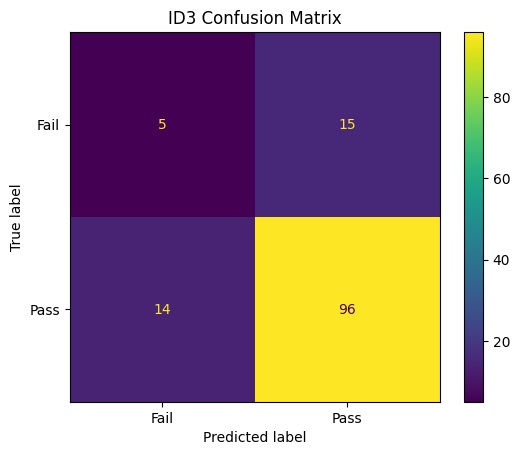

In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Prediction
my_predictions = predict_id3(
    X_test_id3,
    my_id3_tree
)

# Accuracy
my_accuracy = accuracy_score(
    y_test_id3,
    my_predictions
)

print(
    f"My ID3 Test Accuracy: "
    f"{my_accuracy:.4f}"
)

print(
    classification_report(
        y_test_id3,
        my_predictions,
        target_names=["Fail", "Pass"]
    )
)

cm = confusion_matrix(
    y_test_id3,
    my_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
).plot()

plt.title("ID3 Confusion Matrix")
plt.show()